<a href="https://colab.research.google.com/github/vansh-virmani/ML/blob/main/implementing_self_attention.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import torch

In [12]:
inputs=torch.tensor(
    [[0.72, 0.45, 0.31], #dream
[0.75, 0.20, 0.55],#big
[0.30, 0.80, 0.40],# and
[0.85, 0.35, 0.60],# work
[0.55, 0.15, 0.75],# for
[0.25, 0.20, 0.85]# it
]

)
words=['Dream', 'big', 'and', 'work', 'for','it']

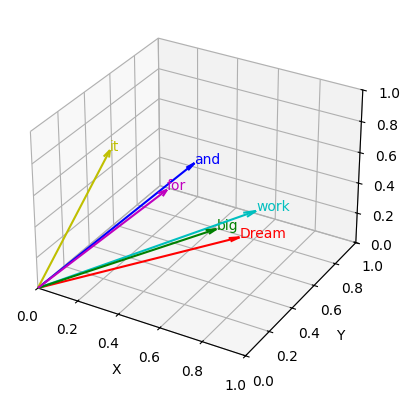

In [13]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
#Extract x,y,z coordinates
x_coords=inputs[:,0].numpy()
y_coords=inputs[:,1].numpy()
z_coords= inputs[:,2].numpy()

##d plot
fig=plt.figure()
ax=fig.add_subplot(111,projection='3d')
colors=['r', 'g', 'b', 'c', 'm', 'y']
for(x,y,z,word, color) in zip(x_coords, y_coords,z_coords,words,colors):
  ax.quiver(0,0,0,x,y,z,color=color,arrow_length_ratio=0.05)
  ax.text(x,y,z,word, fontsize=10, color=color)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_xlim([0,1])
ax.set_ylim([0,1])
ax.set_zlim([0,1])

plt.show()


In [14]:
query = inputs[1] # 2nd input token is the query

attn_scores_2 = torch.empty(inputs.shape[0])
for i, x_i in enumerate(inputs):
    attn_scores_2[i] = torch.dot(x_i, query) # dot product (transpose not necessary her

print(attn_scores_2)


tensor([0.8005, 0.9050, 0.6050, 1.0375, 0.8550, 0.6950])


In [15]:
# attn_weights_2_tmp = attn_scores_2 / attn_scores_2.sum()

# print("Attention weights:", attn_weights_2_tmp)
# print("Sum:", attn_weights_2_tmp.sum())


Attention weights: tensor([0.1634, 0.1848, 0.1235, 0.2118, 0.1746, 0.1419])
Sum: tensor(1.0000)


In [16]:
import tensorflow as tf

# Convert attn_scores_2 to a TensorFlow tensor
attn_scores_2_tf = tf.convert_to_tensor(attn_scores_2.numpy())

attn_weights_2_tmp = tf.nn.softmax(attn_scores_2_tf)

print("Attention weights:", attn_weights_2_tmp.numpy())
print("Sum:", attn_weights_2_tmp.numpy().sum())


Attention weights: [0.16244562 0.18033989 0.13359906 0.20589025 0.1715446  0.14618066]
Sum: 1.0000001


In [19]:
attn_scores= inputs @ inputs.T
print(attn_scores)

tensor([[0.8170, 0.8005, 0.7000, 0.9555, 0.6960, 0.5335],
        [0.8005, 0.9050, 0.6050, 1.0375, 0.8550, 0.6950],
        [0.7000, 0.6050, 0.8900, 0.7750, 0.5850, 0.5750],
        [0.9555, 1.0375, 0.7750, 1.2050, 0.9700, 0.7925],
        [0.6960, 0.8550, 0.5850, 0.9700, 0.8875, 0.8050],
        [0.5335, 0.6950, 0.5750, 0.7925, 0.8050, 0.8250]])


attention scores to attention weights

In [23]:
attn_weights=torch.softmax(attn_scores,dim=1)
print(attn_weights)

tensor([[0.1766, 0.1738, 0.1571, 0.2029, 0.1565, 0.1330],
        [0.1624, 0.1803, 0.1336, 0.2059, 0.1715, 0.1462],
        [0.1675, 0.1523, 0.2025, 0.1805, 0.1493, 0.1478],
        [0.1648, 0.1789, 0.1376, 0.2115, 0.1672, 0.1400],
        [0.1491, 0.1747, 0.1334, 0.1960, 0.1805, 0.1662],
        [0.1396, 0.1641, 0.1455, 0.1809, 0.1831, 0.1868]])


In [24]:
#sum of each row is one
print("All row sums", attn_weights.sum(dim=-1))

All row sums tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000])


In [25]:
#printing context vectors
all_context_vecs=attn_weights @ inputs
print(all_context_vecs)

tensor([[0.5965, 0.3611, 0.5654],
        [0.5982, 0.3431, 0.5794],
        [0.5681, 0.3830, 0.5627],
        [0.6008, 0.3471, 0.5758],
        [0.5859, 0.3377, 0.5900],
        [0.5684, 0.3402, 0.5964]])


In [26]:
context_vec_2 = all_context_vecs[1]
print("Previous 2nd context vector:", context_vec_2)


Previous 2nd context vector: tensor([0.5982, 0.3431, 0.5794])


In [27]:
# Append context_vec_2 to inputs
inputs = torch.cat((inputs, context_vec_2.unsqueeze(0)), dim=0)

# Add 'context_vector' to the words list
words.append('context_vector')

print("Updated inputs tensor:")
print(inputs)
print("\nUpdated words list:")
print(words)


Updated inputs tensor:
tensor([[0.7200, 0.4500, 0.3100],
        [0.7500, 0.2000, 0.5500],
        [0.3000, 0.8000, 0.4000],
        [0.8500, 0.3500, 0.6000],
        [0.5500, 0.1500, 0.7500],
        [0.2500, 0.2000, 0.8500],
        [0.5982, 0.3431, 0.5794]])

Updated words list:
['Dream', 'big', 'and', 'work', 'for', 'it', 'context_vector']


(0.0, 1.0)

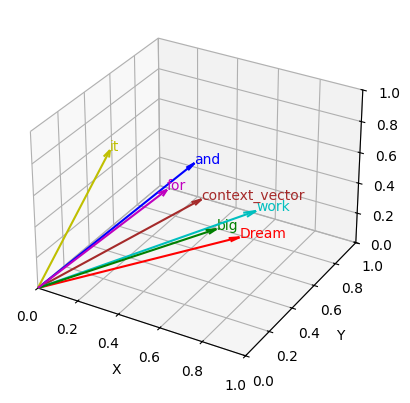

In [28]:
 x_coords = inputs[:, 0].numpy()
y_coords = inputs[:, 1].numpy()
z_coords = inputs[:, 2].numpy()

# 3D plot with vectors from origin
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

colors = ['r', 'g', 'b', 'c', 'm', 'y', 'brown']

for (x, y, z, word, color) in zip(x_coords, y_coords, z_coords, words, colors):
    ax.quiver(0, 0, 0, x, y, z, color=color, arrow_length_ratio=0.05)
    ax.text(x, y, z, word, fontsize=10, color=color)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
ax.set_zlim([0, 1])


In [29]:
# the above is the context vector for big